In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src.plotting_styles import apply_global_style

In [4]:
from src.load_sam_data import load_dataset
from src.autoencoders import drop_empty_histograms
from src.autoencoders import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

..\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [6]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [7]:
import torch.nn as nn

# first model
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(96, 64),  
            nn.ReLU(),

            nn.Linear(64, 32),  
            nn.ReLU(),
            
            nn.Linear(32, 16),  
            nn.Sigmoid(),
            )

        self.decoder = nn.Sequential(
            nn.Linear(16, 32),
            nn.ReLU(),
            
            nn.Linear(32, 64),
            nn.ReLU(),

            nn.Linear(64, 96),
            nn.Sigmoid()
            )
        
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [8]:
from torch.utils.data import Dataset, DataLoader

class HistDataset(Dataset):
    def __init__(self, df):
        self.df = df

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        x = self.df[idx]

        if not torch.is_tensor(x):
            x = torch.tensor(x, dtype=torch.float32)
        
        x = x.unsqueeze(0)
        return x

In [9]:
batch_size = 32
train_dataset = HistDataset(X_train)
test_dataset = HistDataset(X_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

ae_lin = Autoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=ae_lin.parameters(), lr=0.0005)

In [10]:
from src.autoencoders import train_ae

ae_lin.train()
train_losses, val_losses, ae_lin = train_ae(n_epochs=40, dataloader=train_loader, model=ae_lin, val_loader=test_loader, optimizer=optimizer, criterion=criterion)

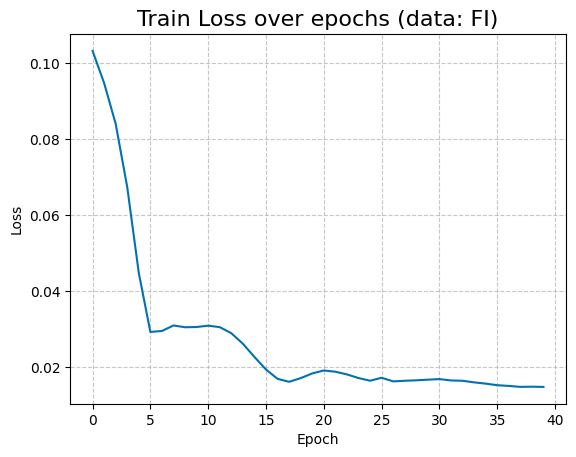

In [11]:
apply_global_style()
plt.title("Train Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(train_losses)), train_losses)
plt.show()

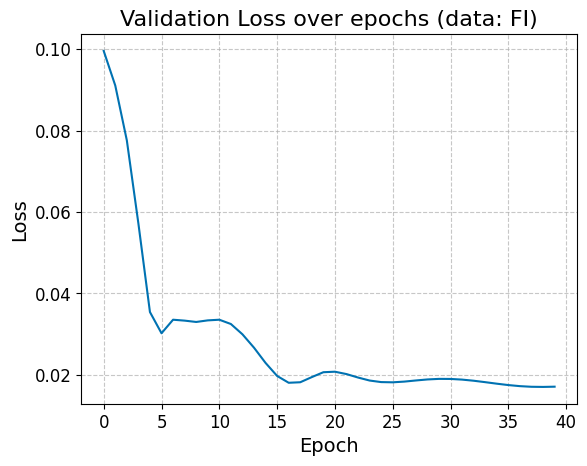

In [12]:
apply_global_style()
plt.title("Validation Loss over epochs (data: FI)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.plot(range(len(val_losses)), val_losses)
plt.show()

c:\Users\hrdyj\coding\vyzkumak\mlenv\Lib\site-packages\torch\nn\modules\loss.py:616: UserWarning: Using a target size (torch.Size([1, 96])) that is different to the input size (torch.Size([1, 1, 96])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


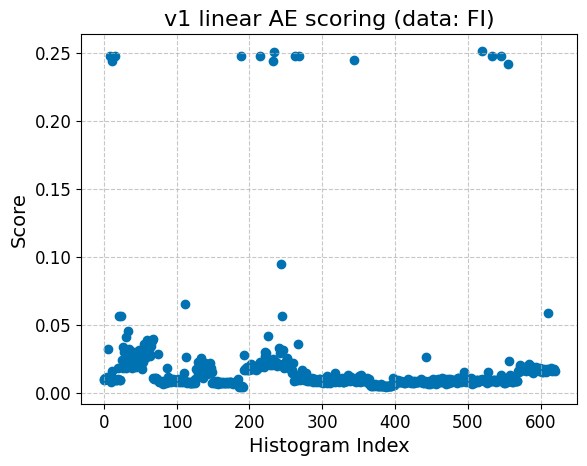

In [13]:
from src.autoencoders import eval_and_plot_score
apply_global_style()
plt.title("v1 linear AE scoring (data: FI)")
plt.xlabel("Histogram Index")
plt.ylabel("Score")

full_dataset = HistDataset(full_dataset)
dataloader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

scores = []

with torch.no_grad():
    ae_lin.eval()
    for pt in full_dataset:
        pred = ae_lin(pt.reshape(1, 1, 96))
        loss = criterion(pred, pt).detach()
        scores.append(loss.numpy())
plt.scatter(range(len(scores)), scores)
plt.show()

In [14]:
outliers = np.where(np.array(scores) > 0.2)
print(len(outliers[0]))
print(outliers[0].tolist())

14
[8, 11, 15, 188, 214, 233, 234, 263, 268, 344, 520, 533, 546, 555]


In [15]:
for idx, pt in enumerate(outliers[0].tolist()):
    if dataset[pt].any() == np.zeros(96).any():
        print(pt)

8
15
188
214
263
268
533
546


In [16]:
preds = list()

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = ae_lin(data).numpy()
         
        for p in preds:
            if pred.all() == p.all():
                break
        else:
            preds.append(pred)
len(preds)

1

tensor(0.0081)


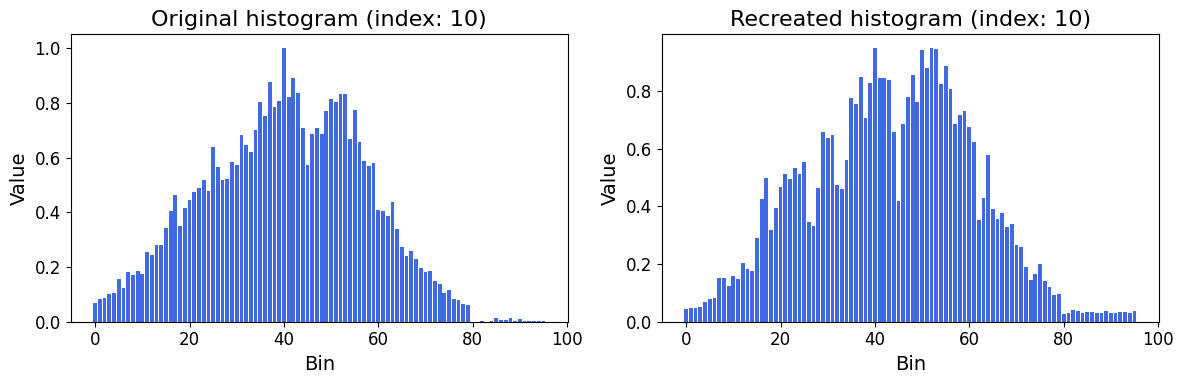

In [17]:
idx = 10

ae_lin.eval()
pred = ae_lin(full_dataset[idx]).detach()

criterion = nn.MSELoss()
loss = criterion(pred, full_dataset[idx])
pred = pred.squeeze().numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(pred)), full_dataset[idx].squeeze(), zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")
#axes[0].grid(True, linestyle='--', alpha=0.7, zorder=-2)

axes[1].bar(range(len(pred)), pred, zorder=1, color='royalblue')
axes[1].set_title(f"Recreated histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")
print(loss)
#axes[1].grid(True, linestyle='--', alpha=0.7, zorder=-2)

plt.tight_layout()
plt.show()

In [ ]:
# score_dict = {idx : s for idx, s in enumerate(score)}
# indexes_sorted_by_score = sorted(score_dict, key=lambda x: score_dict[x], reverse=True)

# print("highest scores", indexes_sorted_by_score[:10] )
# print("lowest scores", indexes_sorted_by_score[-10:])

NameError: name 'score' is not defined

## Let's observe latent space

In [19]:
idx = 20
pt = full_dataset[idx]
ae_lin.eval()
embedding = ae_lin.encoder(full_dataset[idx]).detach()
print(embedding.squeeze().numpy())

[1. 1. 1. 0. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 1. 1.]


In [20]:
enc_preds = list()

with torch.no_grad():
    ae_lin.eval()
    for idx, data in enumerate(full_dataset):
        embed = ae_lin.encoder(data).numpy()
         
        for p in enc_preds:
            if embed.all() == p.all():
                break
        else:
            enc_preds.append(pred)
len(enc_preds)

606

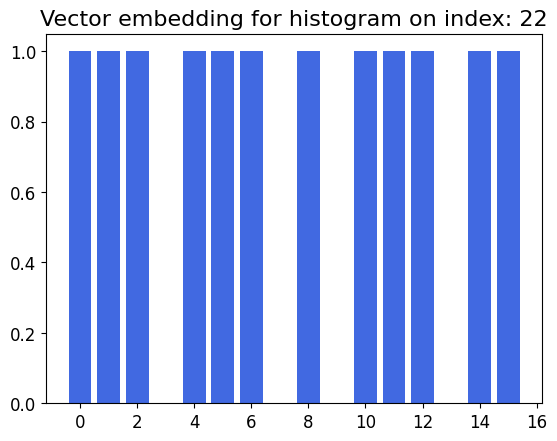

16


In [25]:
idx = 22
pt = full_dataset[idx]

ae_lin.eval()
with torch.no_grad():
    embedding = ae_lin.encoder(pt).squeeze().cpu().numpy()

plt.title(f"Vector embedding for histogram on index: {idx}")
plt.bar(range(len(embedding)), embedding, color='royalblue')
plt.show()
print(len(embedding))

## Let's see scores of random histograms

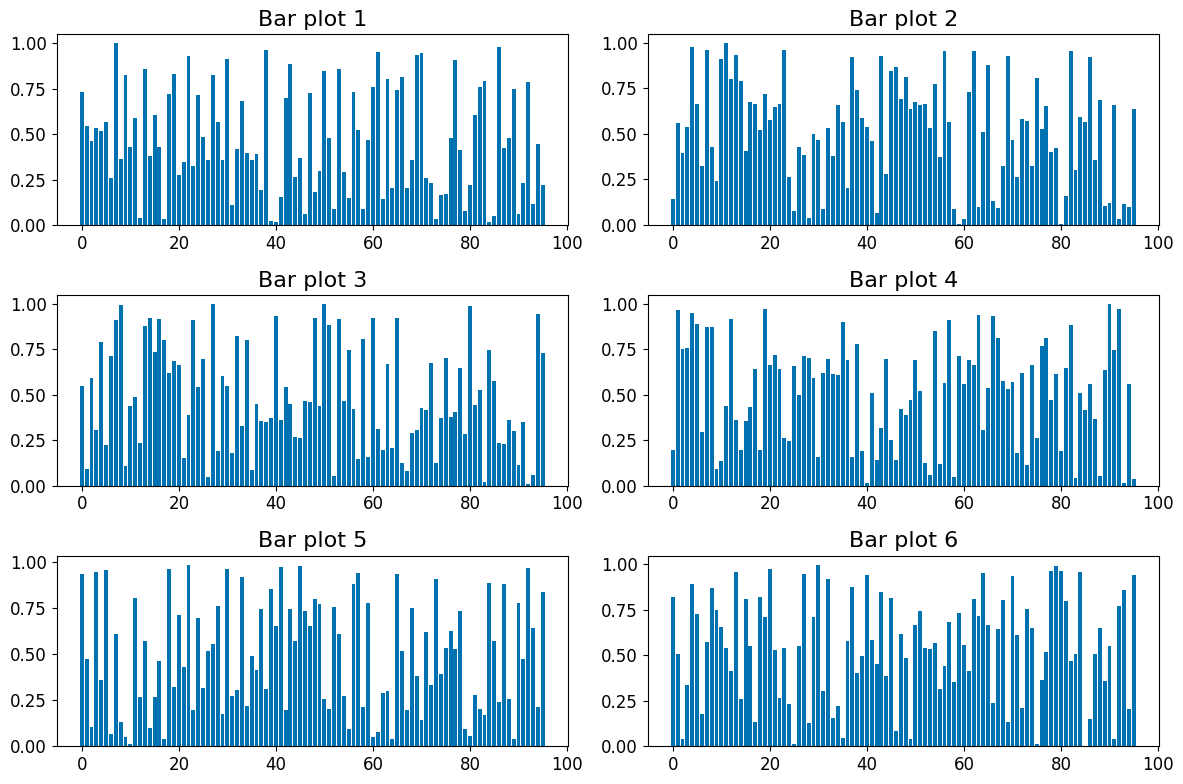

In [22]:
randoms = [torch.rand(96) for _ in range(6)]
import torch
import matplotlib.pyplot as plt

randoms = [torch.rand(96) for _ in range(6)]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (ax, data) in enumerate(zip(axes, randoms)):
    ax.bar(range(len(data)), data)
    ax.set_title(f"Bar plot {i+1}")

plt.tight_layout()
plt.show()

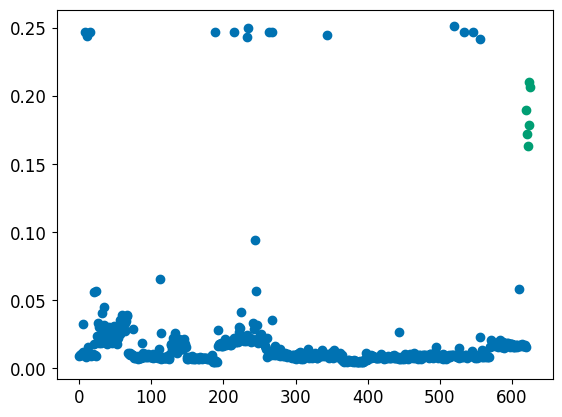

In [23]:
out_scores = []
for out in randoms:
    pred = ae_lin(out)
    loss = criterion(pred, out).detach().numpy()
    out_scores.append(loss)
plt.scatter(range(len(scores)), scores)
plt.scatter(range(len(scores), len(scores) + len(out_scores)), out_scores)
plt.show()

array(0.20671721, dtype=float32)

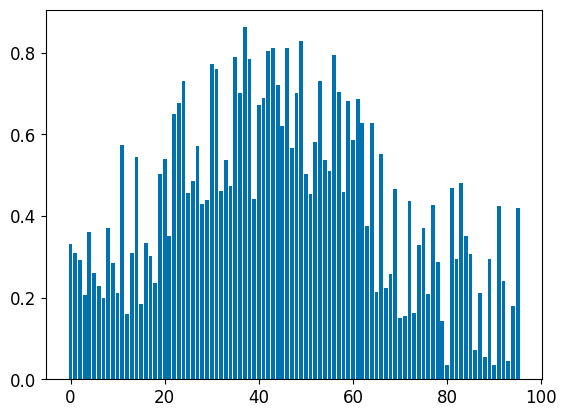

In [24]:
new_pt = (torch.rand(96) + full_dataset[90].reshape(1,96).squeeze())/2

plt.bar(range(len(new_pt)), new_pt)
pred = ae_lin(new_pt)
out_score = criterion(pred, out).detach().numpy()
out_score

In [ ]:
# torch.save({
#     "model_state_dict": ae_lin.state_dict(),
#     "config": {
#         "input_dim": 96,
#         "latent_dim": 16,
#     }
# }, "ae_saved/lin_autoenc_v1.pth")